Neurônio Único (Perceptron)

## 🎯 Objetivo
Entender como funciona um único neurônio artificial e por que precisamos de múltiplos neurônios para resolver problemas de classificação multiclasse.

- **a)** Explicar o que é um Perceptron e sua fórmula matemática
- **b)** Visualizar como um neurônio define uma fronteira (reta) no espaço 2D
- **c)** Comparar funções de ativação: Degrau, Sigmoid e ReLU — diferenças e gradientes
- **d)** Implementar gradiente descendente manualmente para treinar um Perceptron
- **e)** Entender por que precisamos de mais neurônios para separar 3 classes

In [6]:
# imports
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## a) Entendendo o que é um Perceptron

Um Perceptron é a unidade básica de qualquer rede neural. Matematicamente:

$$y = f(\mathbf{w} \cdot \mathbf{x} + b)$$

No qual:
| Símbolo | Nome | Papel |
|---|---|---|
| $\mathbf{x}$ | Entrada | Dados fornecidos ao neurônio |
| $\mathbf{w}$ | Pesos | O que a rede **aprende** |
| $b$ | Bias | Desloca a fronteira de decisão |
| $f$ | Função de ativação | Introduz não-linearidade |
| $y$ | Saída | Predição final |

O **produto interno** $\mathbf{w} \cdot \mathbf{x} = w_1 x_1 + w_2 x_2$ mede o quão "alinhado" está o vetor de entrada com o vetor de pesos.

**Intuição:** o peso $w_i$ determina o quanto a feature $x_i$ influencia a saída.

In [ ]:
# === Simulação passo a passo de UM neurônio, pesos fixos em w e b ===

# Entrada: um ponto em 2D
x = np.array([0.8, 0.6])

# Pesos (serão aprendidos durante o treino)
w = np.array([1.0, -0.5])
b = -0.2  # bias 

# Passo 1: Fazendo o produto interno
z = np.dot(w, x) + b
print(f"Entrada       x  = {x}")
print(f"Pesos         w  = {w}")
print(f"Bias          b  = {b}")
print(f"Produto w·x      = {np.dot(w, x):.4f}")
print(f"Pré-ativação  z  = w·x + b = {z:.4f}\n")

# Passo 2: Aplicando função de ativação
sigmoid = lambda z: 1 / (1 + np.exp(-z))
relu    = lambda z: max(0, z)
print(f"Saída Sigmoid  f(z) = {sigmoid(z):.4f}  → interpretado como probabilidade")
print(f"Saída ReLU     f(z) = {relu(z):.4f}  → ativa apenas se z > 0\n")
print("Se saída > 0.5 → prediz Classe 1")
print("Se saída < 0.5 → prediz Classe 0")

# A loss é MSE sobre essa saída probabilística
# saída do neurônio (probabilidade)
y_hat = sigmoid(z)

# decisão de classe
# Y_tr = np.array([0.0]*(N//2) + [1.0]*(N//2))
# acc = np.mean((y_hat >= 0.5).astype(float) == Y_tr)


Entrada       x  = [0.8 0.6]
Pesos         w  = [ 1.  -0.5]
Bias          b  = -0.2
Produto w·x      = 0.5000
Pré-ativação  z  = w·x + b = 0.3000

Saída Sigmoid  f(z) = 0.5744  → interpretado como probabilidade
Saída ReLU     f(z) = 0.3000  → ativa apenas se z > 0

Se saída > 0.5 → prediz Classe 1
Se saída < 0.5 → prediz Classe 0


## b) Entendendo como um neurônio define uma reta separadora

A equação $w_1 x_1 + w_2 x_2 + b = 0$ é uma **reta** no plano 2D.

Isolando $x_2$:
$$x_2 = -\frac{w_1 x_1 + b}{w_2}$$

- **Pontos acima da reta**: $w_1 x_1 + w_2 x_2 + b > 0$ → o neurônio ativa → Classe 1
- **Pontos abaixo da reta**: $w_1 x_1 + w_2 x_2 + b < 0$ → o neurônio não ativa → Classe 0

> **O vetor de pesos $\mathbf{w}$ é sempre perpendicular (normal) à reta.**  
> O bias $b$ desloca a reta para longe ou para perto da origem.

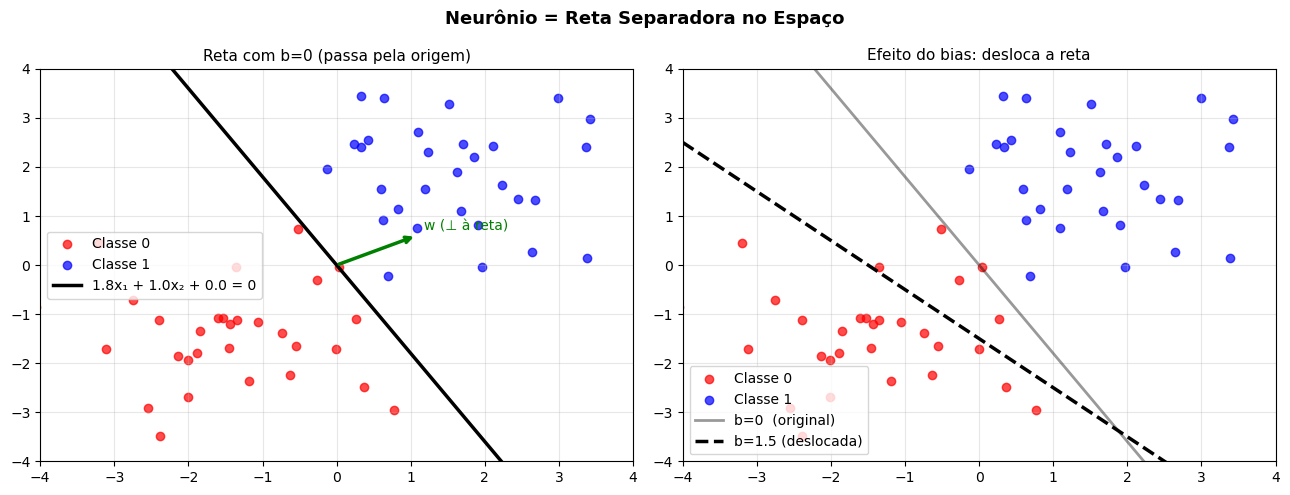

In [10]:
# Olhando a reta separadora de um neurônio
np.random.seed(0)
N = 60
grupo0 = np.random.randn(N//2, 2) + np.array([-1.5, -1.5])  # classe 0
grupo1 = np.random.randn(N//2, 2) + np.array([ 1.5,  1.5])  # classe 1

# === Hiperparâmetro: os pesos definem a orientação da reta ===
# fazer teste 
w1, w2, b = 1.8, 1.0, 0.0

x1_range = np.linspace(-4, 4, 200)
x2_reta  = -(w1 * x1_range + b) / w2   # x2 = -(w1*x1 + b) / w2

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# gráfico 1: (b=0)
axes[0].scatter(grupo0[:, 0], grupo0[:, 1], c='red',  label='Classe 0', alpha=0.7)
axes[0].scatter(grupo1[:, 0], grupo1[:, 1], c='blue', label='Classe 1', alpha=0.7)
axes[0].plot(x1_range, x2_reta, 'k-', linewidth=2.5, label=f'{w1}x₁ + {w2}x₂ + {b} = 0')
axes[0].annotate('', xy=(w1*0.6, w2*0.6), xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color='green', lw=2.5))
axes[0].text(w1*0.6+0.1, w2*0.6+0.1, 'w (⊥ à reta)', color='green', fontsize=10)
axes[0].set_xlim(-4, 4); axes[0].set_ylim(-4, 4)
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_title('Reta com b=0 (passa pela origem)', fontsize=11)

# gráfico 2: ver efeito do bias
w1, w2, b2 = 1.0, 1.0, 1.5
x2_reta2   = -(w1 * x1_range + b2) / w2
axes[1].scatter(grupo0[:, 0], grupo0[:, 1], c='red',  label='Classe 0', alpha=0.7)
axes[1].scatter(grupo1[:, 0], grupo1[:, 1], c='blue', label='Classe 1', alpha=0.7)
axes[1].plot(x1_range, x2_reta,  'k-',  linewidth=2, label=f'b=0  (original)', alpha=0.4)
axes[1].plot(x1_range, x2_reta2, 'k--', linewidth=2.5, label=f'b={b2} (deslocada)')
axes[1].set_xlim(-4, 4); axes[1].set_ylim(-4, 4)
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_title('Efeito do bias: desloca a reta', fontsize=11)

plt.suptitle('Neurônio = Reta Separadora no Espaço', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## c) Funções de Ativação: Degrau, Sigmoid e ReLU

### Por que precisamos de funções de ativação?
Sem elas, empilhar camadas lineares $Wx + b$ é equivalente a **uma única** camada linear. A não-linearidade é o que dá poder expressivo às redes neurais.

### As 3 principais:

| Função | Fórmula | Intervalo de saída | Gradiente | Problema principal |
|---|---|---|---|---|
| **Degrau** | $f(z) = \mathbb{1}[z \geq 0]$ | $\{0, 1\}$ | $= 0$ em quase todo lugar | **Não treinável!** |
| **Sigmoid** | $f(z) = \frac{1}{1+e^{-z}}$ | $(0, 1)$ | $f(z)(1-f(z)) \leq 0.25$ | Vanishing gradient |
| **ReLU** | $f(z) = \max(0, z)$ | $[0, +\infty)$ | $0$ ou $1$ | Dying ReLU |

### Por que o gradiente importa?
O backpropagation multiplica gradientes pela **regra da cadeia**. Se algum gradiente for zero (Degrau) ou muito pequeno (Sigmoid saturada), os pesos das camadas anteriores **param de aprender** — é o chamado **vanishing gradient problem**.

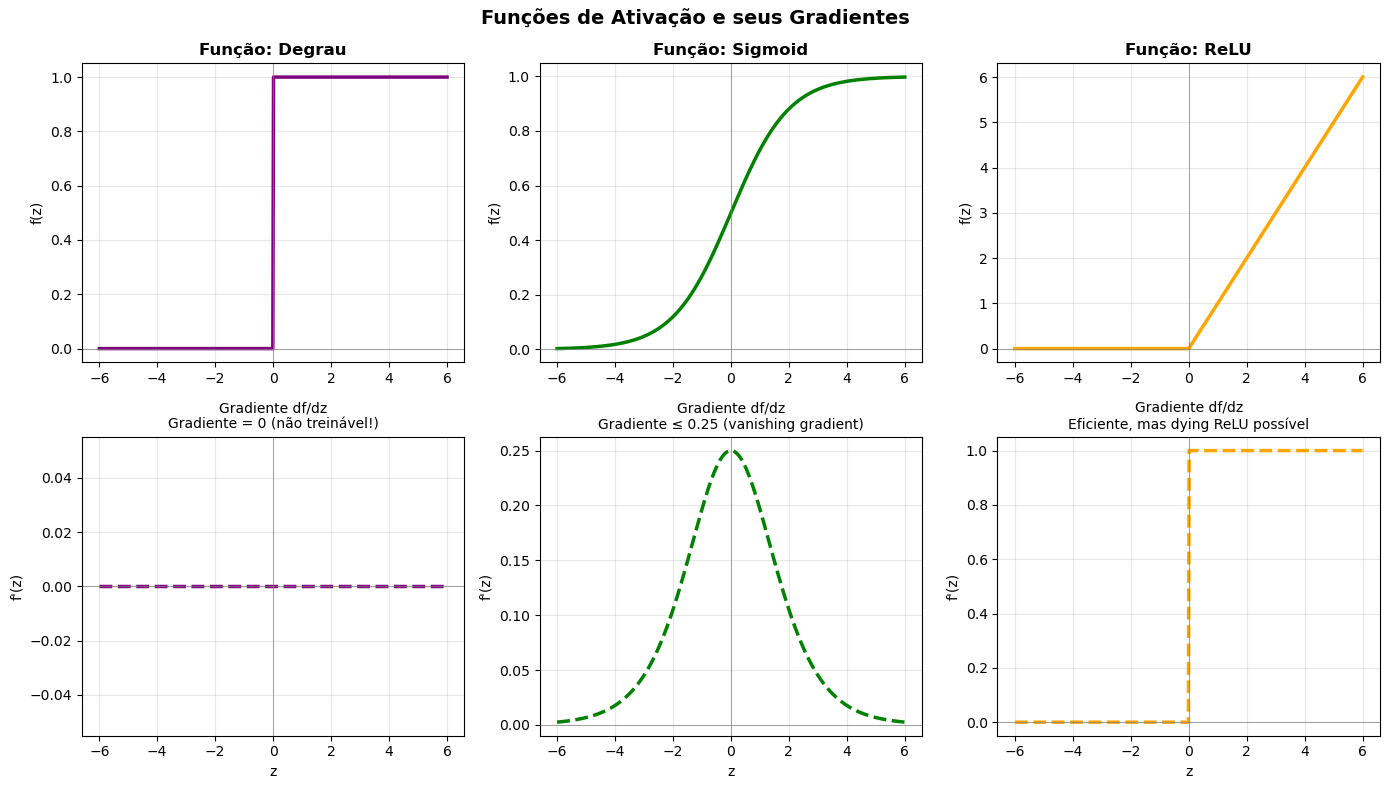

Gradiente máximo da Sigmoid (em z=0): 0.2500
Gradiente do Degrau (em qualquer z) : 0.0000  ← impossível treinar!
Gradiente da ReLU (em z=1)          : 1.0000


In [12]:
# === Comparação visual das 3 funções de ativação ===
z = np.linspace(-6, 6, 500)

# Definições
def degrau(z):     return np.where(z >= 0, 1.0, 0.0)
def sigmoid(z):    return 1 / (1 + np.exp(-z))
def relu(z):       return np.maximum(0, z)

# Gradientes analíticos
def grad_degrau(z):  return np.zeros_like(z)            # zero em quase todo lugar!
def grad_sigmoid(z): s = sigmoid(z); return s * (1 - s)  # máx = 0.25
def grad_relu(z):    return np.where(z > 0, 1.0, 0.0)   # 0 ou 1

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
funcs   = [degrau,       sigmoid,      relu     ]
grads   = [grad_degrau,  grad_sigmoid, grad_relu]
nomes   = ['Degrau',     'Sigmoid',    'ReLU'   ]
cores   = ['purple',     'green',      'orange' ]
problemas = ['Gradiente = 0 (não treinável!)',
             'Gradiente ≤ 0.25 (vanishing gradient)',
             'Eficiente, mas dying ReLU possível']

for col in range(3):
    y = funcs[col](z)
    g = grads[col](z)

    # Linha 0: função
    axes[0, col].plot(z, y, color=cores[col], linewidth=2.5)
    axes[0, col].set_title(f'Função: {nomes[col]}', fontsize=12, fontweight='bold')
    axes[0, col].axhline(0, color='gray', lw=0.5)
    axes[0, col].axvline(0, color='gray', lw=0.5)
    axes[0, col].set_ylabel('f(z)', fontsize=10)
    axes[0, col].grid(True, alpha=0.3)

    # Linha 1: gradiente
    axes[1, col].plot(z, g, color=cores[col], linewidth=2.5, linestyle='--')
    axes[1, col].set_title(f"Gradiente df/dz\n{problemas[col]}", fontsize=10)
    axes[1, col].axhline(0, color='gray', lw=0.5)
    axes[1, col].axvline(0, color='gray', lw=0.5)
    axes[1, col].set_ylabel("f'(z)", fontsize=10)
    axes[1, col].set_xlabel('z', fontsize=10)
    axes[1, col].grid(True, alpha=0.3)

plt.suptitle('Funções de Ativação e seus Gradientes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Gradiente máximo da Sigmoid (em z=0): {grad_sigmoid(np.array([0.0]))[0]:.4f}")
print(f"Gradiente do Degrau (em qualquer z) : {grad_degrau(np.array([1.0]))[0]:.4f}  ← impossível treinar!")
print(f"Gradiente da ReLU (em z=1)          : {grad_relu(np.array([1.0]))[0]:.4f}")

## d) Treinar um Perceptron com Gradiente Descendente

O objetivo do treino é **minimizar a função de perda** $L$ em relação aos pesos $\mathbf{w}$ e $b$.

### Regra de atualização (Gradiente Descendente):
$$w_j \leftarrow w_j - \eta \cdot \frac{\partial L}{\partial w_j}$$
$$b \leftarrow b - \eta \cdot \frac{\partial L}{\partial b}$$

### Derivação dos gradientes (Sigmoid + MSE Loss):

**1. Loss:** $L = \frac{1}{N}\sum(\hat{y}_i - y_i)^2$

**2. Gradiente em relação aos pesos:**
$$\frac{\partial L}{\partial w_j} = \frac{2}{N}\sum_i (\hat{y}_i - y_i) \cdot \hat{y}_i(1-\hat{y}_i) \cdot x_{ij}$$

**3. Gradiente em relação ao bias:**
$$\frac{\partial L}{\partial b} = \frac{2}{N}\sum_i (\hat{y}_i - y_i) \cdot \hat{y}_i(1-\hat{y}_i)$$

### Hiperparâmetros:
| Parâmetro | Descrição | Valor típico | Efeito se muito alto |
|---|---|---|---|
| `learning_rate` η | Tamanho do passo | 0.01 – 0.1 | Oscila / diverge |
| `epochs` | Nº de iterações | 100 – 1000 | Overfitting |

Época 200: Loss=0.0157  Acurácia=0.9875
Pesos aprendidos: w=[0.8814 0.9669], b=-0.1230


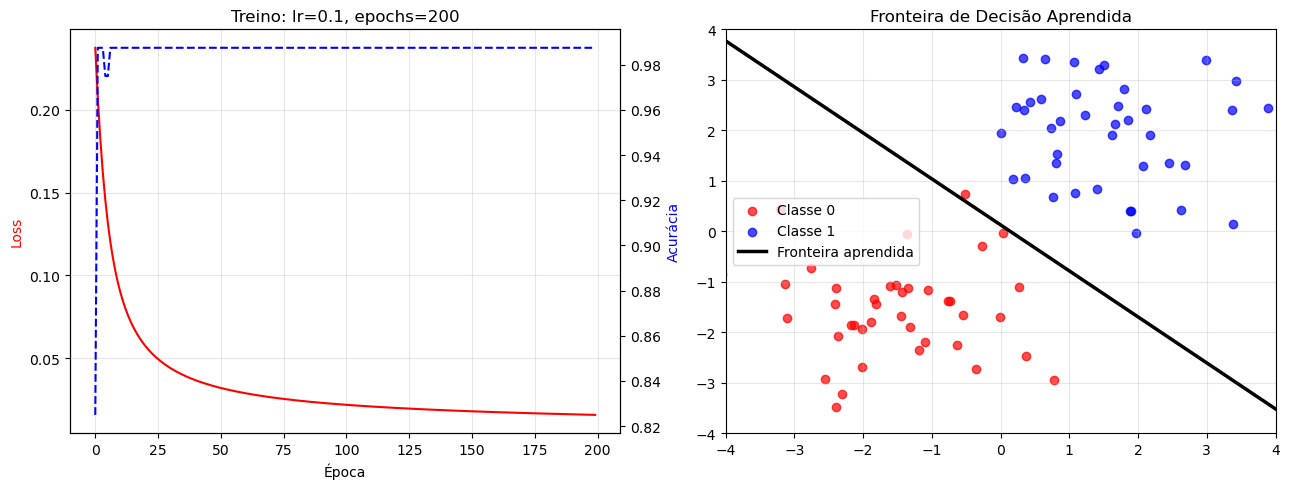

In [13]:
# === Treino manual de um Perceptron passo a passo ===
np.random.seed(0)
N = 80
X_neg = np.random.randn(N//2, 2) + np.array([-1.5, -1.5])
X_pos = np.random.randn(N//2, 2) + np.array([ 1.5,  1.5])
X_tr  = np.vstack([X_neg, X_pos])
Y_tr  = np.array([0.0]*(N//2) + [1.0]*(N//2))

# === HIPERPARÂMETROS (experimente mudar!) ===
learning_rate = 0.1    # taxa de aprendizado
epochs        = 200    # número de épocas

# Inicialização dos pesos (pequenos valores aleatórios)
np.random.seed(42)
w = np.random.randn(2) * 0.1
b = 0.0

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

losses, accs = [], []

for epoch in range(epochs):
    # === FORWARD PASS ===
    z      = X_tr @ w + b        # pré-ativação: shape (N,)
    y_hat  = sigmoid(z)           # saída do neurônio

    # === CÁLCULO DA LOSS (MSE) ===
    loss = np.mean((y_hat - Y_tr) ** 2)
    acc  = np.mean((y_hat >= 0.5).astype(float) == Y_tr)
    losses.append(loss); accs.append(acc)

    # === BACKWARD PASS (gradientes manuais) ===
    dL_dy   = 2 * (y_hat - Y_tr) / N        # dL/d(y_hat)
    dL_dz   = dL_dy * y_hat * (1 - y_hat)   # dy_hat/dz = sigmoid'
    grad_w  = X_tr.T @ dL_dz                # dz/dw = x
    grad_b  = np.sum(dL_dz)                 # dz/db = 1

    # === ATUALIZAÇÃO DOS PESOS ===
    w -= learning_rate * grad_w
    b -= learning_rate * grad_b

print(f"Época {epochs}: Loss={losses[-1]:.4f}  Acurácia={accs[-1]:.4f}")
print(f"Pesos aprendidos: w={w.round(4)}, b={b:.4f}")

# Visualização
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(losses, 'r-', label='Loss (MSE)')
ax1_b = ax1.twinx()
ax1_b.plot(accs, 'b--', label='Acurácia')
ax1.set_xlabel('Época'); ax1.set_ylabel('Loss', color='red')
ax1_b.set_ylabel('Acurácia', color='blue')
ax1.set_title(f'Treino: lr={learning_rate}, epochs={epochs}')
ax1.grid(True, alpha=0.3)

ax2.scatter(X_neg[:, 0], X_neg[:, 1], c='red',  label='Classe 0', alpha=0.7)
ax2.scatter(X_pos[:, 0], X_pos[:, 1], c='blue', label='Classe 1', alpha=0.7)
x1r = np.linspace(-4, 4, 200)
ax2.plot(x1r, -(w[0]*x1r + b)/w[1], 'k-', lw=2.5, label='Fronteira aprendida')
ax2.set_xlim(-4, 4); ax2.set_ylim(-4, 4)
ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.set_title('Fronteira de Decisão Aprendida')

plt.tight_layout(); plt.show()

## e) Por que precisamos de mais neurônios para 3 classes?

Um único neurônio cria **somente uma reta** no espaço 2D. Para separar 3 grupos em posições diferentes, precisamos de **múltiplas retas** — uma para cada fronteira.

No problema do notebook de simple classification dado nas primeiras aulas que tem 3 classes na diagonal:
- A fronteira 1: separa classe 1 (topo) das demais
- A fronteira 2: separa classe 3 (base) das demais

> ai vemos que isso exige **no mínimo 2 neurônios**, e usamos 4 para ter robustez (os pesos $(v,v)$, $(-v,-v)$, $(v,v)$, $(-v,-v)$).

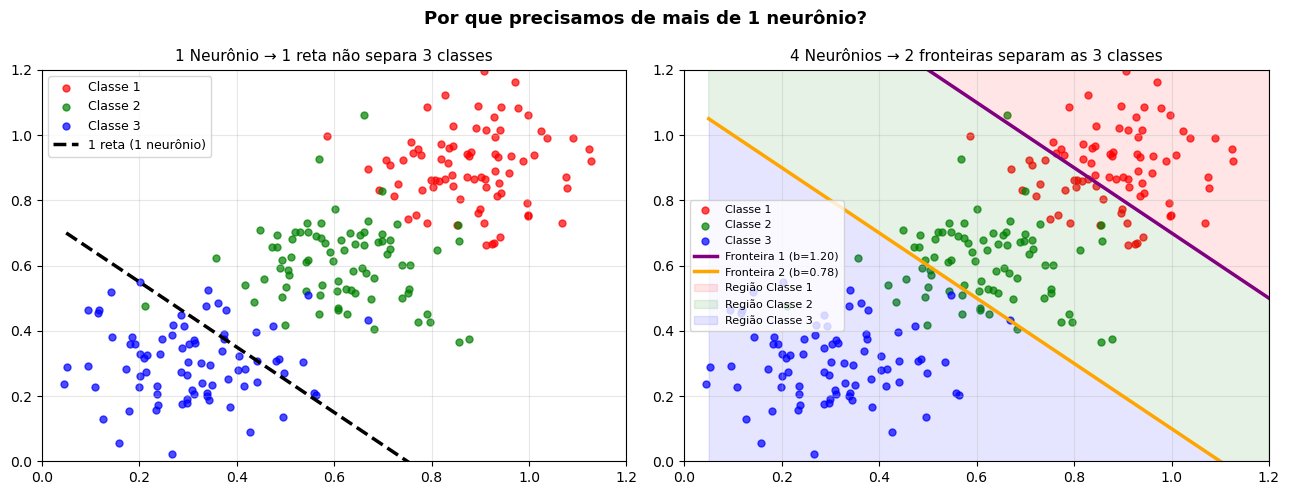

Fronteira 1 (separa classe 1): x1 + x2 = 1.7000  (≈ média de 0.85+0.85 e 0.60+0.60)
Fronteira 2 (separa classe 3): x1 + x2 = 1.1000  (≈ média de 0.60+0.60 e 0.30+0.30)


In [16]:
# 1 neurônio vs 4 neurônios para 3 classes
np.random.seed(42)
N = 80
c1 = np.random.randn(N, 2) * 0.12 + [0.90, 0.90]
c2 = np.random.randn(N, 2) * 0.12 + [0.60, 0.60]
c3 = np.random.randn(N, 2) * 0.12 + [0.30, 0.30]

v  = (2.0**0.5) / 2
b1 = ((0.85)**2 + (0.85)**2)**0.5   # distância geom para fronteira 1
b2 = ((0.55)**2 + (0.55)**2)**0.5   # distância geom para fronteira 2
x1r = np.linspace(0.05, 1.2, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

def plot_data(ax):
    ax.scatter(c1[:,0], c1[:,1], c='red',   label='Classe 1', alpha=0.7, s=25)
    ax.scatter(c2[:,0], c2[:,1], c='green', label='Classe 2', alpha=0.7, s=25)
    ax.scatter(c3[:,0], c3[:,1], c='blue',  label='Classe 3', alpha=0.7, s=25)
    ax.set_xlim(0.0, 1.2); ax.set_ylim(0.0, 1.2)
    ax.grid(True, alpha=0.3)

# 1 neurônio
plot_data(ax1)
ax1.plot(x1r, -x1r + 0.75, 'k--', lw=2.5, label='1 reta (1 neurônio)')
ax1.set_title('1 Neurônio → 1 reta não separa 3 classes', fontsize=11)
ax1.legend(fontsize=9)

# Com 4 neurônios temos 2 fronteiras distintas
plot_data(ax2)
ax2.plot(x1r, -x1r + b1/v, 'purple', lw=2.5, label=f'Fronteira 1 (b={b1:.2f})')
ax2.plot(x1r, -x1r + b2/v, 'orange', lw=2.5, label=f'Fronteira 2 (b={b2:.2f})')
ax2.fill_between(x1r, -x1r + b1/v, 1.2, alpha=0.1, color='red',   label='Região Classe 1')
ax2.fill_between(x1r, -x1r + b2/v, -x1r + b1/v, alpha=0.1, color='green', label='Região Classe 2')
ax2.fill_between(x1r, 0.0, -x1r + b2/v, alpha=0.1, color='blue',  label='Região Classe 3')
ax2.set_title('4 Neurônios → 2 fronteiras separam as 3 classes', fontsize=11)
ax2.legend(fontsize=8)

plt.suptitle('Por que precisamos de mais de 1 neurônio?', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Fronteira 1 (separa classe 1): x1 + x2 = {b1/v:.4f}  (≈ média de 0.85+0.85 e 0.60+0.60)")
print(f"Fronteira 2 (separa classe 3): x1 + x2 = {b2/v:.4f}  (≈ média de 0.60+0.60 e 0.30+0.30)")